In [58]:
import torch

path = "/home/jian/gaussian-splatting/debug/_DSC8695.JPG/merge_inputs.pt"
data = torch.load(path, map_location="cpu")
print(data.keys())
for k, v in data.items():
    if isinstance(v, list):
        print(k, len(v))



dict_keys(['all_renders', 'all_depths', 'all_alphas', 'all_viewspace_points', 'all_visibility_filter', 'all_radii'])
all_renders 16
all_depths 16
all_alphas 16
all_viewspace_points 16
all_visibility_filter 16
all_radii 16


In [ ]:
def merge(
    render_list,
    depth_list,
    alphaLeft_list,
    cache_viewspace_points_list=None,
    cache_visibility_filters_list=None,
    cache_radii_list=None,
    eps=1e-10
):
    """
    Multi-block compositing for partitioned Gaussian rendering.

    Inputs per block k:
        render_list[k]  : [3, H, W] RGB -> 这个 block 自己贡献给这个像素的总颜色
        depth_list[k]   : [1, H, W] depth
        alphaLeft_list[k]: [H, W] or [1, H, W] -> 光线穿过这个 block 之后剩下的透射率（还没被前面挡掉的比例）

        cache_viewspace_points_list[k]: [N_k, 3]
        cache_visibility_filters_list[k]: [M_k, 1] or [M_k]
        cache_radii_list[k]: [N_k]

    Returns:
        final_rgb      : [3, H, W]
        bg_rgb         : [3, H, W]
        final_depth    : [1, H, W]
        merged_vps     : [sum_k N_k, 3] or None
        merged_vis_idx : [sum_k M_k, 1] or None (indices into merged_radii)
        merged_radii   : [sum_k N_k] or None
    """

    


    K = len(render_list)
    assert K > 0, "render_list is empty"

    device = render_list[0].device
    dtype  = render_list[0].dtype

    # ------------------------
    # 0. stack tensors
    # ------------------------
    # RGB: [K, 3, H, W]
    renders = torch.stack(render_list, dim=0)

    # depth: 保证 [K, 1, H, W]
    depth_tensors = []
    for d in depth_list:
        if d.dim() == 2:
            depth_tensors.append(d.unsqueeze(0))
        elif d.dim() == 3:
            depth_tensors.append(d)
        else:
            raise ValueError(f"depth dim must be 2 or 3, got {d.dim()}")
    depths = torch.stack(depth_tensors, dim=0)  # [K,1,H,W]

    # alphaLeft: 保证 [K, 1, H, W]
    alpha_tensors = []
    for a in alphaLeft_list:
        if a.dim() == 2:
            alpha_tensors.append(a.unsqueeze(0))
        elif a.dim() == 3:
            alpha_tensors.append(a)
        else:
            raise ValueError(f"alphaLeft dim must be 2 or 3, got {a.dim()}")
    alphas = torch.stack(alpha_tensors, dim=0)  # [K,1,H,W]

    _, C, H, W = renders.shape
    assert C == 3, f"render channel should be 3, got {C}"

    # ------------------------
    # 1. sort pixels along depth
    # ------------------------
    # 如果你的 depth 是 "越大越近" 或 "inverse depth"，这里可以改成 descending=True/False
    sort_idx = torch.argsort(depths.squeeze(1), dim=0, descending=True)  # [K,H,W]

    # RGB 排序
    idx_rgb = sort_idx.unsqueeze(1).expand(-1, C, -1, -1)        # [K,3,H,W]
    front_rgbs = torch.gather(renders, 0, idx_rgb)               # [K,3,H,W]

    # alpha 排序
    idx_alpha = sort_idx.unsqueeze(1)                            # [K,1,H,W]
    front_alphas = torch.gather(alphas, 0, idx_alpha)            # [K,1,H,W]

    # depth 排序（用于 final_depth）
    front_depths = torch.gather(depths, 0, idx_alpha)            # [K,1,H,W]

    # ------------------------
    # 2. forward compositing
    # ------------------------
    # cumT[k] = prod_{i<=k} alpha_i
    cumT = torch.cumprod(front_alphas, dim=0)                    # [K,1,H,W]
    # prefix_T[k] = prod_{i<k} alpha_i
    prefix_T = torch.cat([torch.ones_like(cumT[:1]), cumT[:-1]], dim=0)  # [K,1,H,W]

    # color & depth 合成
    final_rgb   = (prefix_T * front_rgbs).sum(dim=0)       # [3,H,W]
    final_rgb = final_rgb.clamp(0, 1)

    
    

    final_depth = (prefix_T * front_depths).sum(dim=0)           # [1,H,W]

    # ------------------------
    # 3. background color
    # ------------------------
    log_front_Ts = torch.log(front_alphas.clamp(min=eps))        # [K,1,H,W]
    log_post_prod_inc   = torch.cumsum(log_front_Ts.flip(0), dim=0).flip(0)
    log_post_prod_shift = torch.cat(
        [log_post_prod_inc[1:], torch.zeros_like(log_post_prod_inc[:1])],
        dim=0
    )

    inv_scale    = torch.exp(-log_post_prod_inc).clamp(max=1e6)
    C_scaled     = front_rgbs * inv_scale
    suffix_sum_C = torch.cumsum(C_scaled.flip(0), dim=0).flip(0) - C_scaled
    scale        = torch.exp(log_post_prod_shift)
    suffix_color = scale * suffix_sum_C
    bg_rgb       = suffix_color[0]                               # [3,H,W]

    # ------------------------
    # 4. merge caches (viewspace_points, radii, visibility_filter)
    # ------------------------
    final_viewspace_points   = None
    final_radii = None
    final_visibility_filter   = None

    # 4.1 viewspace_points: 直接 cat
    if cache_viewspace_points_list is not None and len(cache_viewspace_points_list) > 0:
        final_viewspace_points = torch.cat(cache_viewspace_points_list, dim=0)

    # 4.2 radii: 直接 cat
    if cache_radii_list is not None and len(cache_radii_list) > 0:
        final_radii = torch.cat(cache_radii_list, dim=0)

    # 4.3 visibility_filter: 需要做 index offset 后 cat
    if (
        cache_visibility_filters_list is not None
        and cache_radii_list is not None
        and len(cache_visibility_filters_list) == len(cache_radii_list)
    ):
        vis_list = []
        offset = 0
        for vf, radii in zip(cache_visibility_filters_list, cache_radii_list):
            num_r = radii.shape[0]

            if vf is None or vf.numel() == 0:
                offset += num_r
                continue

            # vf 可能是 [M,1] 或 [M]
            if vf.dim() == 2 and vf.size(1) == 1:
                local_idx = vf[:, 0]
            else:
                local_idx = vf.view(-1)

            global_idx = local_idx + offset
            vis_list.append(global_idx)

            offset += num_r

        if len(vis_list) > 0:
            final_visibility_filter = torch.cat(vis_list, dim=0).unsqueeze(1)  # [M_total,1]
        else:
            final_visibility_filter = torch.empty(
                (0, 1), dtype=torch.long, device=device
            )

    # ------- 新增：计算 block_rank -------
    # sort_idx[k,h,w] = block_id
    # block_rank[block_id,h,w] = k     (反向映射）
    K, H, W = sort_idx.shape
    flat = sort_idx.reshape(K, -1)        # [K,HW]
    br = torch.empty_like(flat)
    cols = torch.arange(flat.shape[1])

    for k in range(K):
        br[ flat[k], cols ] = k

    block_rank = br.reshape(K, H, W)

    
    return {
        "final_rgb": final_rgb,
        "bg_rgb": bg_rgb,
        "final_depth": final_depth,
        "final_viewspace_points": final_viewspace_points,
        "final_visibility_filter": final_visibility_filter,
        "final_radii": final_radii,
        "sort_idx": sort_idx,
        "front_rgbs": front_rgbs,
        "front_alphas": front_alphas,
        "prefix_T": prefix_T,
        "block_rank": block_rank
    }

In [60]:

cpu_merge_result = merge(
    data["all_renders"],
    data["all_depths"],
    data["all_alphas"],
    data["all_viewspace_points"],
    data["all_visibility_filter"],
    data["all_radii"],
)


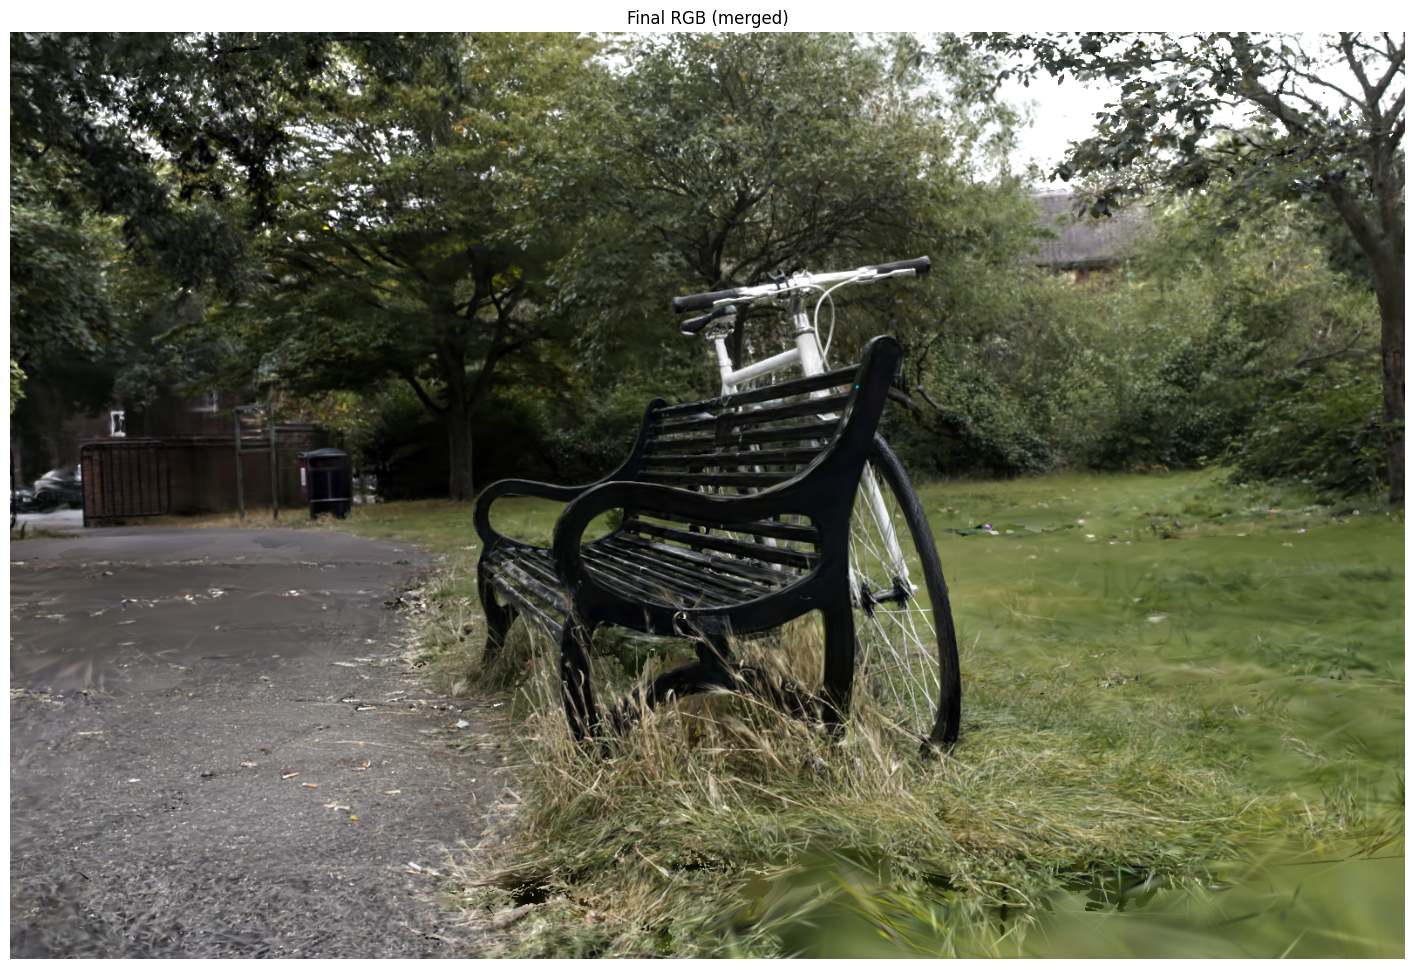

In [61]:
import torch
import matplotlib.pyplot as plt
final_rgb = cpu_merge_result["final_rgb"]  # [3,H,W]

# [3,H,W] -> [H,W,3]
img = final_rgb.permute(1, 2, 0).numpy()

plt.figure(figsize=(18, 16))
plt.imshow(img)
plt.axis("off")
plt.title("Final RGB (merged)")
plt.show()


In [62]:
C_sorted   = cpu_merge_result["front_rgbs"]      # [K,3,H,W]
T_sorted   = cpu_merge_result["front_alphas"]    # [K,1,H,W]
prefix_T  = cpu_merge_result["prefix_T"]         # [K,1,H,W]
sort_idx  = cpu_merge_result["sort_idx"]         # [K,H,W]
block_rank= cpu_merge_result["block_rank"]       # [K,H,W]
radii_cpu = cpu_merge_result["final_radii"]      # [N]

print(sort_idx.shape)

torch.Size([16, 1063, 1600])


In [63]:
import os
import matplotlib.pyplot as plt

debug_dir = "debug/C_sorted"
os.makedirs(debug_dir, exist_ok=True)

K = C_sorted.shape[0]

for k in range(K):
    img = C_sorted[k].permute(1, 2, 0).clamp(0, 1).numpy()

    plt.figure(figsize=(14, 13))
    plt.imshow(img)
    plt.title(f"C_sorted[{k}]")
    plt.axis("off")

    save_path = os.path.join(debug_dir, f"C_sorted_{k:03d}.png")
    plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
    plt.close()   # ⭐ 必须 close，防止 Jupyter 爆内存

    if k % 10 == 0:
        print(f"saved {k}/{K}")


saved 0/16
saved 10/16


In [64]:
debug_dir = "debug/T_sorted"
os.makedirs(debug_dir, exist_ok=True)

for k in range(K):
    T = T_sorted[k, 0].numpy()

    plt.figure(figsize=(14, 13))
    plt.imshow(T, cmap="gray")
    plt.axis("off")

    plt.savefig(
        os.path.join(debug_dir, f"T_sorted_{k:03d}.png"),
        bbox_inches="tight",
        pad_inches=0
    )
    plt.close()


In [65]:
debug_dir = "debug/block_rank"
os.makedirs(debug_dir, exist_ok=True)

for b in range(block_rank.shape[0]):
    rank_map = block_rank[b].numpy()

    plt.figure(figsize=(14, 13))
    plt.imshow(rank_map, cmap="viridis")
    plt.axis("off")

    plt.savefig(
        os.path.join(debug_dir, f"block_rank_{b:03d}.png"),
        bbox_inches="tight",
        pad_inches=0
    )
    plt.close()


In [66]:
debug_dir = "debug/prefix_T"
os.makedirs(debug_dir, exist_ok=True)

for k in range(K):
    T = prefix_T[k, 0].numpy()   # [H, W]

    plt.figure(figsize=(14, 13))
    plt.imshow(T, cmap="gray", vmin=0.0, vmax=1.0)
    plt.colorbar()               # ⭐ 强烈建议，加上立刻不迷糊
    plt.title(f"prefix_T[{k}]")
    plt.axis("off")

    plt.savefig(
        os.path.join(debug_dir, f"prefix_T_{k:03d}.png"),
        bbox_inches="tight",
        pad_inches=0
    )
    plt.close()
